# PHY 657 — Module 5 Homework: Neural Networks
## Spring 2026 - Belal Menbari

---

In [52]:
import numpy as np
import sys
!{sys.executable} -m pip install torch torchvision
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_moons
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

plt.rcParams.update({'font.size': 13, 'figure.figsize': (8, 6)})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


---
# Problem 1: 

Network: 2 inputs → hidden layer with 2 neurons (sigmoid) → 1 output (sigmoid).

Given weights:

$$W^{(1)} = \begin{pmatrix} 0.5 & -0.3 \\ 0.2 & 0.8 \end{pmatrix}, \quad \mathbf{b}^{(1)} = \begin{pmatrix} 0.1 \\ -0.1 \end{pmatrix}$$

$$\mathbf{w}^{(2)} = \begin{pmatrix} 0.6 \\ -0.4 \end{pmatrix}, \quad b^{(2)} = 0.2$$

Input $\mathbf{x} = (1.0,\; 0.5)^T$, true label $y = 1$.

---

## (a) Forward Pass

**Hidden layer pre-activations:**

$$z_1^{(1)} = W_{11}^{(1)} x_1 + W_{12}^{(1)} x_2 + b_1^{(1)} = 0.5(1.0) + (-0.3)(0.5) + 0.1 = 0.5 - 0.15 + 0.1 = 0.45$$

$$z_2^{(1)} = W_{21}^{(1)} x_1 + W_{22}^{(1)} x_2 + b_2^{(1)} = 0.2(1.0) + 0.8(0.5) + (-0.1) = 0.2 + 0.4 - 0.1 = 0.5$$

**Hidden layer activations** ($\sigma(z) = 1/(1+e^{-z})$):

$$h_1 = \sigma(0.45) = \frac{1}{1 + e^{-0.45}} \approx 0.6106$$

$$h_2 = \sigma(0.5) = \frac{1}{1 + e^{-0.5}} \approx 0.6225$$

**Output pre-activation:**

$$z^{(2)} = w_1^{(2)} h_1 + w_2^{(2)} h_2 + b^{(2)} = 0.6(0.6106) + (-0.4)(0.6225) + 0.2$$
$$= 0.3664 - 0.2490 + 0.2 = 0.3174$$

**Output:**

$$\hat{y} = \sigma(z^{(2)}) = \sigma(0.3174) \approx 0.5787$$

In [53]:
# Verify numerically
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

x = np.array([1.0, 0.5])
W1 = np.array([[0.5, -0.3], [0.2, 0.8]])
b1 = np.array([0.1, -0.1])
w2 = np.array([0.6, -0.4])
b2 = 0.2

z1 = W1 @ x + b1
h = sigmoid(z1)
z2_out = w2 @ h + b2
y_hat = sigmoid(z2_out)

print(f'z1 = {z1}')
print(f'h  = {h}')
print(f'z2 = {z2_out:.4f}')
print(f'y_hat = {y_hat:.4f}')

z1 = [0.45 0.5 ]
h  = [0.61063923 0.62245933]
z2 = 0.3174
y_hat = 0.5787


## (b) Loss

Binary cross-entropy for one sample:

$$\mathcal{L} = -\left[ y \ln \hat{y} + (1-y) \ln(1-\hat{y}) \right]$$

With $y=1$, $\hat{y} \approx 0.5787$:

$$\mathcal{L} = -\ln(0.5787) \approx 0.5466$$

In [54]:
y_true = 1.0
loss = -(y_true * np.log(y_hat) + (1 - y_true) * np.log(1 - y_hat))
print(f'Loss = {loss:.4f}')

Loss = 0.5470


## (c) Backward Pass

We propagate gradients from the output backward using the chain rule.

**Output error signal:**

For BCE loss with sigmoid output, the derivative simplifies nicely:

$$\delta^{(2)} = \frac{\partial \mathcal{L}}{\partial z^{(2)}} = \hat{y} - y = 0.5787 - 1 = -0.4213$$

**Gradients for output layer:**

$$\frac{\partial \mathcal{L}}{\partial w_j^{(2)}} = \delta^{(2)} \cdot h_j$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}^{(2)}} = \delta^{(2)} \begin{pmatrix} h_1 \\ h_2 \end{pmatrix} = -0.4213 \begin{pmatrix} 0.6106 \\ 0.6225 \end{pmatrix} = \begin{pmatrix} -0.2572 \\ -0.2623 \end{pmatrix}$$

$$\frac{\partial \mathcal{L}}{\partial b^{(2)}} = \delta^{(2)} = -0.4213$$

**Hidden layer error signal:**

$$\delta_j^{(1)} = \delta^{(2)} \cdot w_j^{(2)} \cdot \sigma'(z_j^{(1)})$$

where $\sigma'(z) = \sigma(z)(1 - \sigma(z)) = h_j(1 - h_j)$.

$$\delta_1^{(1)} = (-0.4213)(0.6)(0.6106)(1 - 0.6106) = (-0.4213)(0.6)(0.2379) \approx -0.0601$$

$$\delta_2^{(1)} = (-0.4213)(-0.4)(0.6225)(1 - 0.6225) = (-0.4213)(-0.4)(0.2350) \approx 0.0396$$

**Gradients for hidden layer:**

$$\frac{\partial \mathcal{L}}{\partial W_{jk}^{(1)}} = \delta_j^{(1)} \cdot x_k$$

$$\frac{\partial \mathcal{L}}{\partial W^{(1)}} = \boldsymbol{\delta}^{(1)} \mathbf{x}^T = \begin{pmatrix} -0.0601 \\ 0.0396 \end{pmatrix} \begin{pmatrix} 1.0 & 0.5 \end{pmatrix} = \begin{pmatrix} -0.0601 & -0.0301 \\ 0.0396 & 0.0198 \end{pmatrix}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(1)}} = \boldsymbol{\delta}^{(1)} = \begin{pmatrix} -0.0601 \\ 0.0396 \end{pmatrix}$$

In [55]:
# Verify backward pass
delta2 = y_hat - y_true
dw2 = delta2 * h
db2_grad = delta2
delta1 = delta2 * w2 * h * (1 - h)
dW1 = np.outer(delta1, x)
db1_grad = delta1

print(f'delta2 = {delta2:.4f}')
print(f'dL/dw2 = {dw2}')
print(f'dL/db2 = {db2_grad:.4f}')
print(f'delta1 = {delta1}')
print(f'dL/dW1 =\n{dW1}')
print(f'dL/db1 = {db1_grad}')

delta2 = -0.4213
dL/dw2 = [-0.25726815 -0.26224807]
dL/db2 = -0.4213
delta1 = [-0.06010207  0.03960372]
dL/dW1 =
[[-0.06010207 -0.03005104]
 [ 0.03960372  0.01980186]]
dL/db1 = [-0.06010207  0.03960372]


## (d) Update

With $\eta = 0.1$:

$$\mathbf{w}^{(2)}_{\text{new}} = \mathbf{w}^{(2)} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{w}^{(2)}}$$

$$= \begin{pmatrix} 0.6 \\ -0.4 \end{pmatrix} - 0.1 \begin{pmatrix} -0.2572 \\ -0.2623 \end{pmatrix} = \begin{pmatrix} 0.6257 \\ -0.3738 \end{pmatrix}$$

$$b^{(2)}_{\text{new}} = 0.2 - 0.1(-0.4213) = 0.2421$$

Both weights increased — the network adjusts to push $\hat{y}$ closer to $y=1$.

In [56]:
eta = 0.1
w2_new = w2 - eta * dw2
b2_new = b2 - eta * db2_grad
print(f'w2_new = {w2_new}')
print(f'b2_new = {b2_new:.4f}')

w2_new = [ 0.62572682 -0.37377519]
b2_new = 0.2421


## (e) Interpretation

It is called "backpropagation" because the **error signal** (how wrong the output is) is **propagated backward** through the network, layer by layer. Specifically, $\delta^{(2)}$ at the output gets multiplied by the weights $w_j^{(2)}$ and the local derivative $\sigma'(z_j^{(1)})$ to produce $\delta^{(1)}$ at the hidden layer. This is just the chain rule applied in reverse — the gradient of the loss flows backward from the output to the input.

---
# Problem 2: 

---

## Helper functions

In [57]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

## (a) Tanh activation — forward and backward

Hidden layer uses $\tanh$, output layer keeps sigmoid.

Forward:
$$\mathbf{z}^{(1)} = X W^{(1)T} + \mathbf{b}^{(1)}, \quad \mathbf{h} = \tanh(\mathbf{z}^{(1)})$$
$$z^{(2)} = \mathbf{h} \cdot \mathbf{w}^{(2)} + b^{(2)}, \quad \hat{y} = \sigma(z^{(2)})$$

Backward: the only change is $\sigma'(z) = h(1-h)$ becomes $\tanh'(z) = 1 - h^2$:

$$\delta^{(2)} = \hat{y} - y$$
$$\delta_j^{(1)} = \delta^{(2)} w_j^{(2)} (1 - h_j^2)$$

In [72]:
def forward_tanh(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = np.tanh(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

def backward_tanh(X, y, y_hat, h, W2):
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * (1 - h**2)   # tanh derivative
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

def train_network(X, y, fwd_fn, bwd_fn, H=4, lr=0.5, n_epochs=5000, seed=0):
    rng = np.random.default_rng(seed)
    N, D = X.shape
    W1 = rng.standard_normal((H, D)) * 0.5
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * 0.5
    b2 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h = fwd_fn(X, W1, b1, W2, b2)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g = bwd_fn(X, y, y_hat, h, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
    return W1, b1, W2, b2, losses

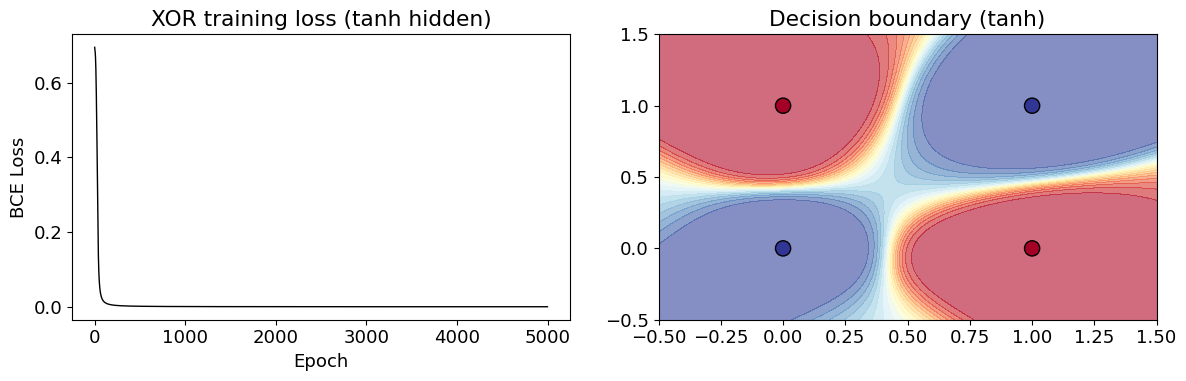

Predictions: [0. 1. 1. 0.]
Converged ✓


In [73]:
# Verify on XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

W1_xor, b1_xor, W2_xor, b2_xor, losses_xor = train_network(
    X_xor, y_xor, forward_tanh, backward_tanh, H=4, lr=2.0, n_epochs=5000
)

y_pred_xor, _ = forward_tanh(X_xor, W1_xor, b1_xor, W2_xor, b2_xor)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_xor, 'k-', lw=1)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('XOR training loss (tanh hidden)')

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z, _ = forward_tanh(grid, W1_xor, b1_xor, W2_xor, b2_xor)
Z = Z.reshape(xx.shape)
axes[1].contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdYlBu_r', edgecolors='k', s=120, zorder=5)
axes[1].set_title('Decision boundary (tanh)')
plt.tight_layout(); plt.show()

print('Predictions:', np.round(y_pred_xor, 3))
print('Converged ✓' if losses_xor[-1] < 0.05 else 'Did not converge')

## (b) Two moons dataset — tanh network vs logistic regression

In [60]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=0, stratify=y_moons
)

# Logistic regression baseline
clf_lr = LogisticRegression().fit(X_tr_m, y_tr_m)
acc_lr = accuracy_score(y_te_m, clf_lr.predict(X_te_m))
print(f'Logistic regression test accuracy: {acc_lr:.4f}')

# Tanh network, H=10
W1_m, b1_m, W2_m, b2_m, losses_m = train_network(
    X_tr_m, y_tr_m.astype(float), forward_tanh, backward_tanh,
    H=10, lr=1.0, n_epochs=5000
)

y_pred_m, _ = forward_tanh(X_te_m, W1_m, b1_m, W2_m, b2_m)
acc_nn = accuracy_score(y_te_m, (y_pred_m > 0.5).astype(int))
print(f'Tanh network test accuracy: {acc_nn:.4f}')

Logistic regression test accuracy: 0.8667
Tanh network test accuracy: 0.9567


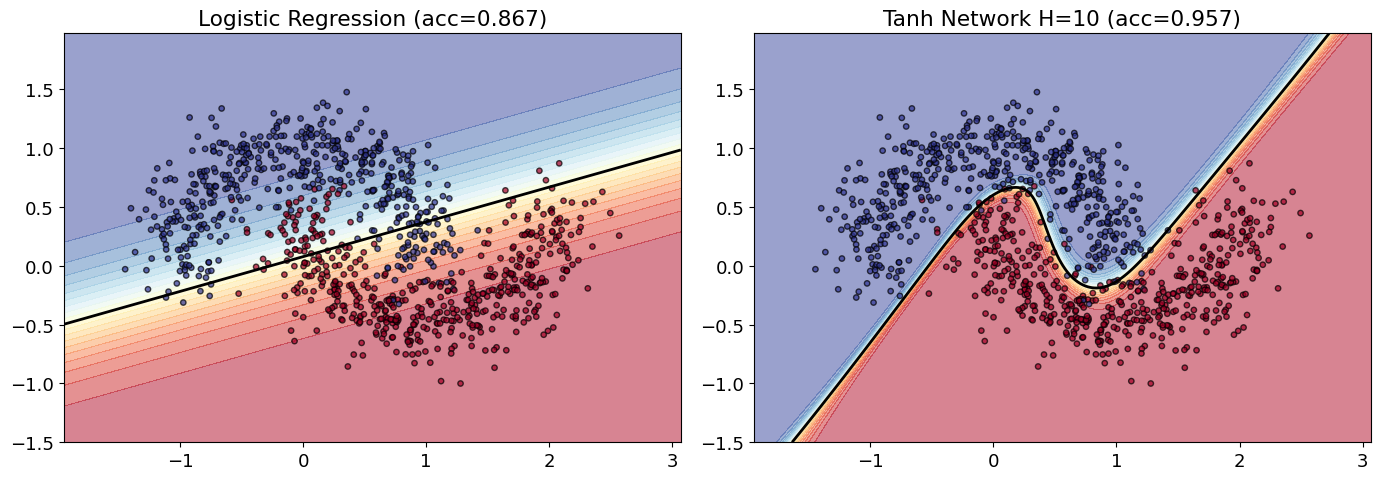

In [61]:
def plot_decision_boundary(ax, fwd_fn, W1, b1, W2, b2, X, y, title=''):
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 300),
        np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z, _ = fwd_fn(grid, W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu_r', edgecolors='k', s=15, alpha=0.7)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR boundary
xx, yy = np.meshgrid(
    np.linspace(X_moons[:, 0].min()-0.5, X_moons[:, 0].max()+0.5, 300),
    np.linspace(X_moons[:, 1].min()-0.5, X_moons[:, 1].max()+0.5, 300)
)
Z_lr = clf_lr.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
axes[0].contourf(xx, yy, Z_lr, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.5)
axes[0].contour(xx, yy, Z_lr, levels=[0.5], colors='k', linewidths=2)
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlBu_r', edgecolors='k', s=15, alpha=0.7)
axes[0].set_title(f'Logistic Regression (acc={acc_lr:.3f})')

plot_decision_boundary(axes[1], forward_tanh, W1_m, b1_m, W2_m, b2_m,
                       X_moons, y_moons, title=f'Tanh Network H=10 (acc={acc_nn:.3f})')

plt.tight_layout(); plt.show()

## (c) Two hidden layers

Architecture: input → $H_1$ neurons (tanh) → $H_2$ neurons (tanh) → 1 output (sigmoid).

Forward pass:
$$\mathbf{z}^{(1)} = X W^{(1)T} + \mathbf{b}^{(1)}, \quad \mathbf{h}^{(1)} = \tanh(\mathbf{z}^{(1)})$$
$$\mathbf{z}^{(2)} = \mathbf{h}^{(1)} W^{(2)T} + \mathbf{b}^{(2)}, \quad \mathbf{h}^{(2)} = \tanh(\mathbf{z}^{(2)})$$
$$z^{(3)} = \mathbf{h}^{(2)} \cdot \mathbf{w}^{(3)} + b^{(3)}, \quad \hat{y} = \sigma(z^{(3)})$$

Backward pass (chain rule through three layers):
$$\delta^{(3)} = \hat{y} - y$$
$$\delta^{(2)} = (\delta^{(3)} \mathbf{w}^{(3)T}) \odot (1 - \mathbf{h}^{(2)2})$$
$$\delta^{(1)} = (\delta^{(2)} W^{(2)}) \odot (1 - \mathbf{h}^{(1)2})$$

In [62]:
def forward_3layer(X, W1, b1, W2, b2, W3, b3):
    z1 = X @ W1.T + b1
    h1 = np.tanh(z1)
    z2 = h1 @ W2.T + b2
    h2 = np.tanh(z2)
    z3 = h2 @ W3 + b3
    y_hat = sigmoid(z3)
    return y_hat, h1, h2

def backward_3layer(X, y, y_hat, h1, h2, W2, W3):
    N = len(y)
    # output layer
    delta3 = (y_hat - y)                        # (N,)
    dW3 = (h2.T @ delta3) / N                   # (H2,)
    db3 = np.mean(delta3)
    # second hidden layer
    delta2 = np.outer(delta3, W3) * (1 - h2**2) # (N, H2)
    dW2 = (delta2.T @ h1) / N                   # (H2, H1)
    db2 = np.mean(delta2, axis=0)                # (H2,)
    # first hidden layer
    delta1 = (delta2 @ W2) * (1 - h1**2)        # (N, H1)
    dW1 = (delta1.T @ X) / N                     # (H1, D)
    db1 = np.mean(delta1, axis=0)                # (H1,)
    return dW1, db1, dW2, db2, dW3, db3

def train_3layer(X, y, H1=10, H2=5, lr=1.0, n_epochs=5000, seed=0):
    rng = np.random.default_rng(seed)
    N, D = X.shape
    W1 = rng.standard_normal((H1, D)) * 0.5
    b1 = np.zeros(H1)
    W2 = rng.standard_normal((H2, H1)) * 0.5
    b2 = np.zeros(H2)
    W3 = rng.standard_normal(H2) * 0.5
    b3 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h1, h2 = forward_3layer(X, W1, b1, W2, b2, W3, b3)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g, dW3, db3_g = backward_3layer(X, y, y_hat, h1, h2, W2, W3)
        W1 -= lr * dW1;  b1 -= lr * db1_g
        W2 -= lr * dW2;  b2 -= lr * db2_g
        W3 -= lr * dW3;  b3 -= lr * db3_g
    return W1, b1, W2, b2, W3, b3, losses

In [63]:
# Train [10, 5] on two moons
W1_3, b1_3, W2_3, b2_3, W3_3, b3_3, losses_3 = train_3layer(
    X_tr_m, y_tr_m.astype(float), H1=10, H2=5, lr=1.0, n_epochs=5000
)

y_pred_3, _, _ = forward_3layer(X_te_m, W1_3, b1_3, W2_3, b2_3, W3_3, b3_3)
acc_3layer = accuracy_score(y_te_m, (y_pred_3 > 0.5).astype(int))
print(f'Two-layer network [10, 5] test accuracy: {acc_3layer:.4f}')
print(f'Single-layer network [10] test accuracy:  {acc_nn:.4f}')

Two-layer network [10, 5] test accuracy: 0.9633
Single-layer network [10] test accuracy:  0.9567


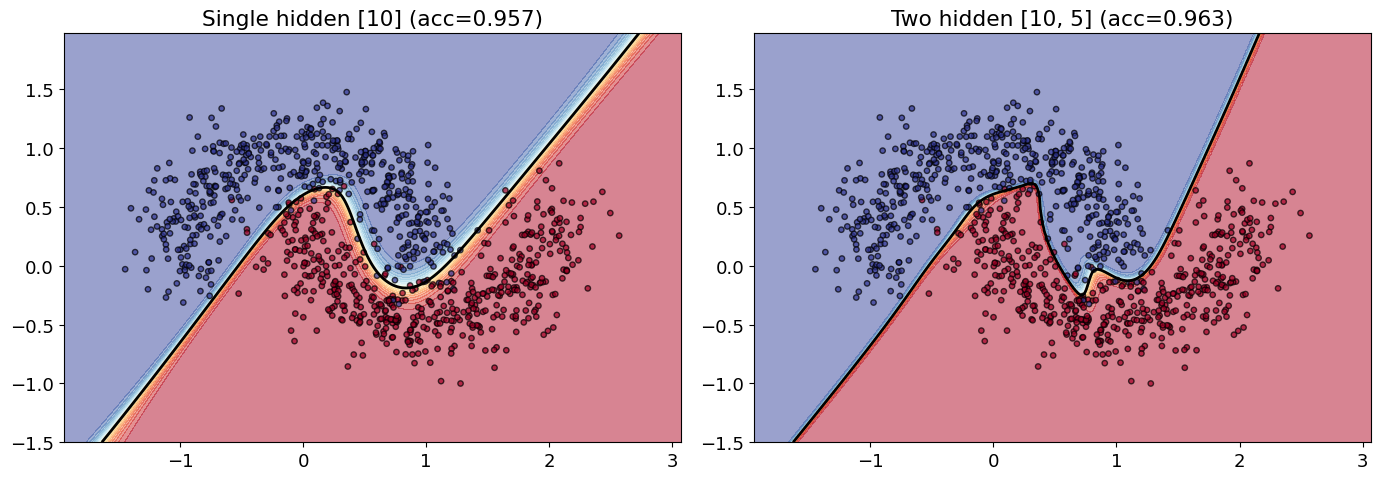

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single layer
plot_decision_boundary(axes[0], forward_tanh, W1_m, b1_m, W2_m, b2_m,
                       X_moons, y_moons, title=f'Single hidden [10] (acc={acc_nn:.3f})')

# Two hidden layers
xx, yy = np.meshgrid(
    np.linspace(X_moons[:, 0].min()-0.5, X_moons[:, 0].max()+0.5, 300),
    np.linspace(X_moons[:, 1].min()-0.5, X_moons[:, 1].max()+0.5, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_3, _, _ = forward_3layer(grid, W1_3, b1_3, W2_3, b2_3, W3_3, b3_3)
Z_3 = Z_3.reshape(xx.shape)
axes[1].contourf(xx, yy, Z_3, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.5)
axes[1].contour(xx, yy, Z_3, levels=[0.5], colors='k', linewidths=2)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlBu_r', edgecolors='k', s=15, alpha=0.7)
axes[1].set_title(f'Two hidden [10, 5] (acc={acc_3layer:.3f})')

plt.tight_layout(); plt.show()

## (d) Discussion

The hardest part of adding the second layer was getting the backward pass right. You have to carefully track which weight matrix and which activation derivative to use at each step — one wrong transpose or mismatched dimension breaks everything silently (the code runs but the network doesn't learn). I had to check the shapes of every intermediate matrix to debug it.

This is exactly why PyTorch exists: automatic differentiation means you only write the forward pass, and the framework handles the chain rule for you. No more shape bugs in hand-derived gradients.

---
# Problem 3: 

---

In [65]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader  = DataLoader(mnist_test, batch_size=1000, shuffle=False)

# Numpy arrays for sklearn
X_train_np = mnist_train.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train_np = mnist_train.targets.numpy()
X_test_np  = mnist_test.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test_np  = mnist_test.targets.numpy()

print(f'Training: {len(mnist_train)}, Test: {len(mnist_test)}')
print(f'Image shape: 28x28 = 784 features, 10 classes')

Training: 60000, Test: 10000
Image shape: 28x28 = 784 features, 10 classes


## Part A: Baseline and first network

### (a) Visualize digits

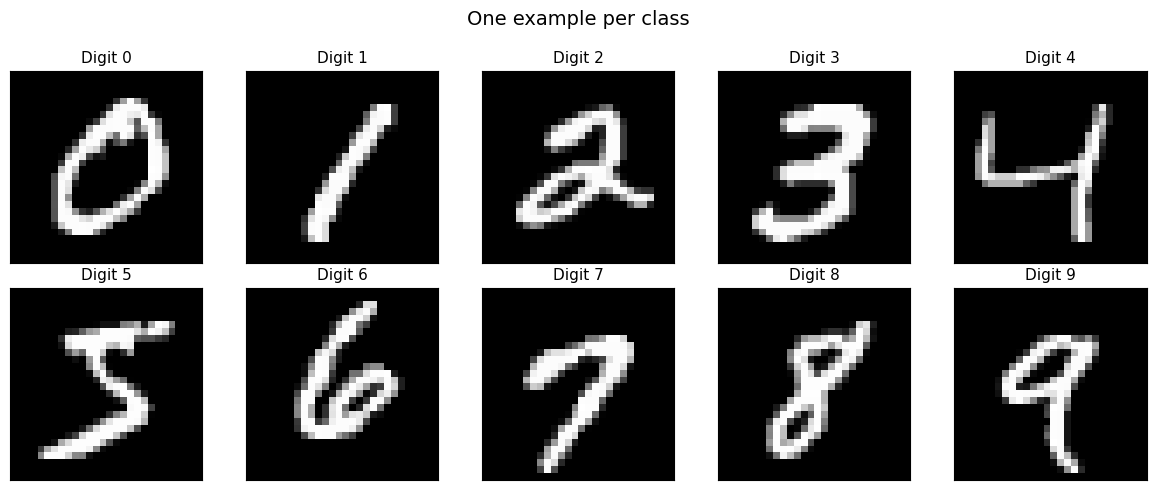

In [66]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_train_np == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(X_train_np[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Digit {digit}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('One example per class', fontsize=14)
plt.tight_layout(); plt.show()

### (b) Logistic regression baseline

Logistic regression test accuracy: 0.9259


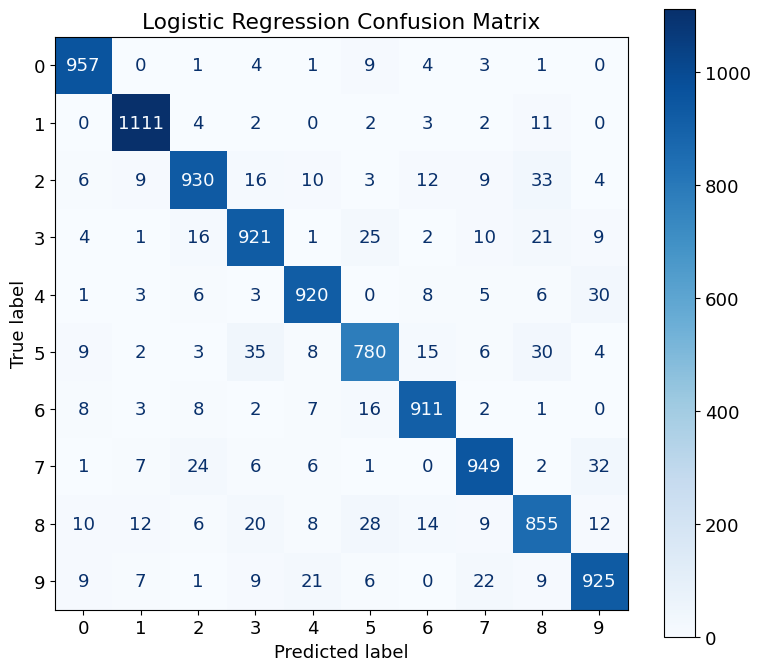

Most confused digit pairs:
  3 ↔ 5: 60 errors
  5 ↔ 8: 58 errors
  7 ↔ 9: 54 errors
  4 ↔ 9: 51 errors
  3 ↔ 8: 41 errors


In [67]:
clf_mnist = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
clf_mnist.fit(X_train_np, y_train_np)
y_pred_lr = clf_mnist.predict(X_test_np)
acc_lr_mnist = accuracy_score(y_test_np, y_pred_lr)
print(f'Logistic regression test accuracy: {acc_lr_mnist:.4f}')

cm = confusion_matrix(y_test_np, y_pred_lr)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Logistic Regression Confusion Matrix')
plt.tight_layout(); plt.show()

# Most confused pairs: look at off-diagonal elements
np.fill_diagonal(cm, 0)
pairs = []
for i in range(10):
    for j in range(i+1, 10):
        pairs.append((cm[i, j] + cm[j, i], i, j))
pairs.sort(reverse=True)
print('Most confused digit pairs:')
for count, i, j in pairs[:5]:
    print(f'  {i} ↔ {j}: {count} errors')

### (c) One hidden layer network (H=128, ReLU)

Multi-class: 10 output neurons, softmax + cross-entropy loss. `nn.CrossEntropyLoss` applies softmax internally, so the output layer is linear.

In [68]:
class MNISTNet(nn.Module):
    def __init__(self, hidden_sizes, input_dim=784, output_dim=10):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, output_dim))  # no activation — CrossEntropyLoss handles softmax
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x.view(x.size(0), -1))


def train_mnist(model, train_loader, test_loader, lr=0.001, n_epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        n_batches = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1
        train_losses.append(running_loss / n_batches)

        model.eval()
        test_loss = 0.0
        n_test = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out = model(X_batch)
                test_loss += criterion(out, y_batch).item()
                n_test += 1
        test_losses.append(test_loss / n_test)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d} | Train loss: {train_losses[-1]:.4f} | Test loss: {test_losses[-1]:.4f}')

    return train_losses, test_losses


def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model(X_batch)
            preds = out.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return correct / total, np.array(all_preds), np.array(all_labels)

In [69]:
# Train [128] network
net_128 = MNISTNet([128]).to(device)
losses_128_tr, losses_128_te = train_mnist(net_128, train_loader, test_loader, n_epochs=20)
acc_128, _, _ = evaluate(net_128, test_loader)
print(f'\n[128] Test accuracy: {acc_128:.4f}')
print(f'Logistic regression:  {acc_lr_mnist:.4f}')
print(f'Improvement: +{acc_128 - acc_lr_mnist:.4f}')

Epoch   5 | Train loss: 0.0563 | Test loss: 0.0867
Epoch  10 | Train loss: 0.0231 | Test loss: 0.0783
Epoch  15 | Train loss: 0.0095 | Test loss: 0.0844
Epoch  20 | Train loss: 0.0055 | Test loss: 0.1012

[128] Test accuracy: 0.9773
Logistic regression:  0.9259
Improvement: +0.0514


## Part B: Architecture and regularization

### (d) Width and depth

In [70]:
# Subsample to 10k for faster experiments
idx_sub = np.random.RandomState(42).choice(len(mnist_train), 10000, replace=False)
sub_train = torch.utils.data.Subset(mnist_train, idx_sub)
sub_loader = DataLoader(sub_train, batch_size=128, shuffle=True)

architectures = {
    '[32]':         [32],
    '[128]':        [128],
    '[256]':        [256],
    '[128,64,32]':  [128, 64, 32],
}

results = {}
for name, hidden in architectures.items():
    print(f'\nTraining {name}...')
    model = MNISTNet(hidden).to(device)
    tr_loss, te_loss = train_mnist(model, sub_loader, test_loader, n_epochs=20)
    acc, _, _ = evaluate(model, test_loader)
    results[name] = {'model': model, 'tr': tr_loss, 'te': te_loss, 'acc': acc}
    print(f'{name} → test acc = {acc:.4f}')


Training [32]...
Epoch   5 | Train loss: 0.2316 | Test loss: 0.2620
Epoch  10 | Train loss: 0.1447 | Test loss: 0.2247
Epoch  15 | Train loss: 0.0972 | Test loss: 0.2099
Epoch  20 | Train loss: 0.0657 | Test loss: 0.2241
[32] → test acc = 0.9363

Training [128]...
Epoch   5 | Train loss: 0.1535 | Test loss: 0.2227
Epoch  10 | Train loss: 0.0575 | Test loss: 0.1712
Epoch  15 | Train loss: 0.0217 | Test loss: 0.1712
Epoch  20 | Train loss: 0.0090 | Test loss: 0.1692
[128] → test acc = 0.9564

Training [256]...
Epoch   5 | Train loss: 0.1161 | Test loss: 0.1871
Epoch  10 | Train loss: 0.0288 | Test loss: 0.1635
Epoch  15 | Train loss: 0.0082 | Test loss: 0.1603
Epoch  20 | Train loss: 0.0035 | Test loss: 0.1700
[256] → test acc = 0.9589

Training [128,64,32]...
Epoch   5 | Train loss: 0.1673 | Test loss: 0.2041
Epoch  10 | Train loss: 0.0592 | Test loss: 0.1811
Epoch  15 | Train loss: 0.0174 | Test loss: 0.1792
Epoch  20 | Train loss: 0.0043 | Test loss: 0.1989
[128,64,32] → test acc = 0

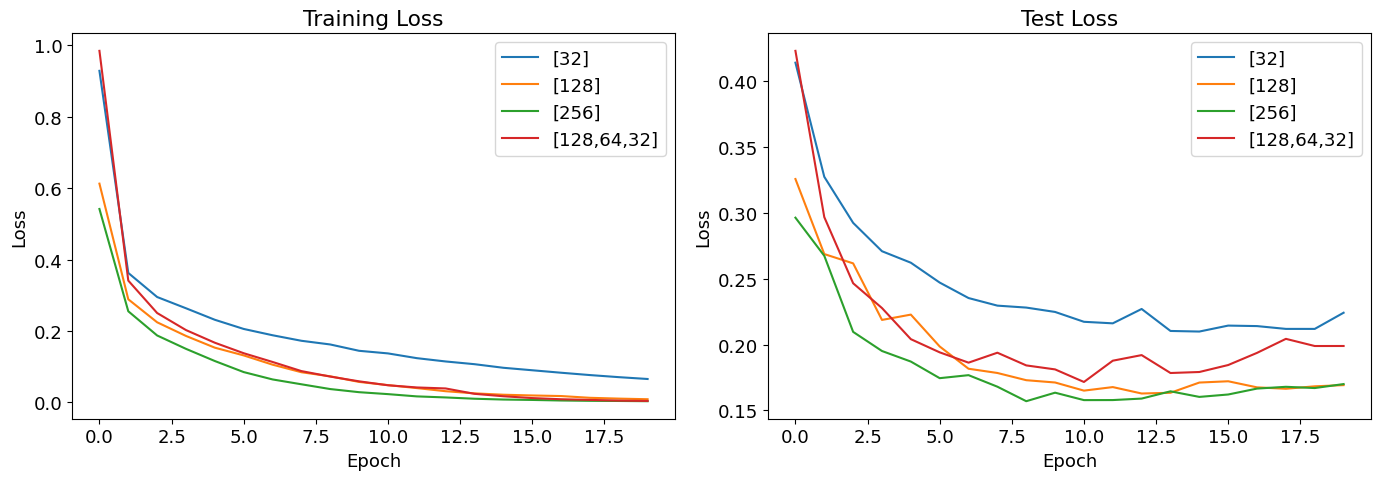


Accuracy summary:
Architecture      Test Acc
---------------------------
[32]                0.9363
[128]               0.9564
[256]               0.9589
[128,64,32]         0.9560


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['tr'], label=name)
    axes[1].plot(r['te'], label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Test Loss')
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

print('\nAccuracy summary:')
print(f'{"Architecture":<15} {"Test Acc":>10}')
print('-' * 27)
for name, r in results.items():
    print(f'{name:<15} {r["acc"]:>10.4f}')

### (e) Overfitting with 500 samples

Epoch   5 | Train loss: 0.6674 | Test loss: 0.7476
Epoch  10 | Train loss: 0.2246 | Test loss: 0.5339
Epoch  15 | Train loss: 0.0929 | Test loss: 0.5057
Epoch  20 | Train loss: 0.0420 | Test loss: 0.5265
Epoch  25 | Train loss: 0.0210 | Test loss: 0.5437
Epoch  30 | Train loss: 0.0107 | Test loss: 0.5760
Epoch  35 | Train loss: 0.0071 | Test loss: 0.5962
Epoch  40 | Train loss: 0.0051 | Test loss: 0.6144
Epoch  45 | Train loss: 0.0038 | Test loss: 0.6314
Epoch  50 | Train loss: 0.0030 | Test loss: 0.6441
Epoch  55 | Train loss: 0.0024 | Test loss: 0.6589
Epoch  60 | Train loss: 0.0020 | Test loss: 0.6717
Epoch  65 | Train loss: 0.0017 | Test loss: 0.6826
Epoch  70 | Train loss: 0.0014 | Test loss: 0.6949
Epoch  75 | Train loss: 0.0012 | Test loss: 0.7043
Epoch  80 | Train loss: 0.0010 | Test loss: 0.7124
Epoch  85 | Train loss: 0.0009 | Test loss: 0.7209
Epoch  90 | Train loss: 0.0008 | Test loss: 0.7287
Epoch  95 | Train loss: 0.0007 | Test loss: 0.7371
Epoch 100 | Train loss: 0.0006 

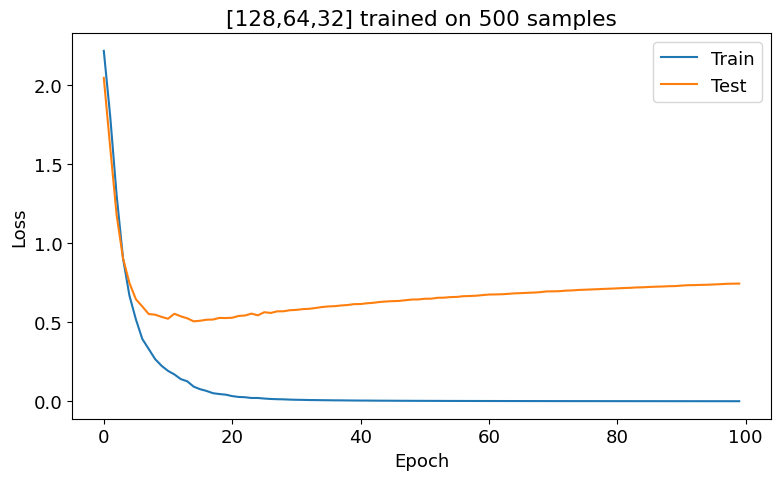

Test loss minimum at epoch 15 (loss = 0.5057)
Test loss at epoch 100: 0.7444
Gap grows after epoch ~15 → overfitting.


In [23]:
idx_500 = np.random.RandomState(0).choice(len(mnist_train), 500, replace=False)
sub_500 = torch.utils.data.Subset(mnist_train, idx_500)
loader_500 = DataLoader(sub_500, batch_size=64, shuffle=True)

net_overfit = MNISTNet([128, 64, 32]).to(device)
tr_loss_of, te_loss_of = train_mnist(net_overfit, loader_500, test_loader, n_epochs=100, lr=0.001)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tr_loss_of, label='Train')
ax.plot(te_loss_of, label='Test')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('[128,64,32] trained on 500 samples')
ax.legend()
plt.tight_layout(); plt.show()

# Find where test loss starts increasing
min_idx = np.argmin(te_loss_of)
print(f'Test loss minimum at epoch {min_idx + 1} (loss = {te_loss_of[min_idx]:.4f})')
print(f'Test loss at epoch 100: {te_loss_of[-1]:.4f}')
print(f'Gap grows after epoch ~{min_idx + 1} → overfitting.')

### (f) Early stopping

In [24]:
def train_with_early_stopping(model, train_loader, test_loader, lr=0.001, n_epochs=100, patience=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []
    best_loss = float('inf')
    best_state = None
    best_epoch = 0

    for epoch in range(n_epochs):
        model.train()
        running = 0.0
        nb = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            running += loss.item()
            nb += 1
        train_losses.append(running / nb)

        model.eval()
        tl = 0.0; nt = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                tl += criterion(model(X_b), y_b).item()
                nt += 1
        test_losses.append(tl / nt)

        if test_losses[-1] < best_loss:
            best_loss = test_losses[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch + 1

    return train_losses, test_losses, best_state, best_epoch


net_es = MNISTNet([128, 64, 32]).to(device)
tr_es, te_es, best_state, best_ep = train_with_early_stopping(
    net_es, loader_500, test_loader, n_epochs=100
)

# Full-run accuracy
acc_full, _, _ = evaluate(net_es, test_loader)

# Early-stopped accuracy
net_es.load_state_dict(best_state)
acc_es, _, _ = evaluate(net_es, test_loader)

print(f'Early-stopped model (epoch {best_ep}): {acc_es:.4f}')
print(f'Full training (epoch 100):            {acc_full:.4f}')
print(f'Useful training epochs: ~{best_ep}')

Early-stopped model (epoch 16): 0.8589
Full training (epoch 100):            0.8587
Useful training epochs: ~16


In [ ]:
## Part C: Inspection

### (g) Visualize learned features

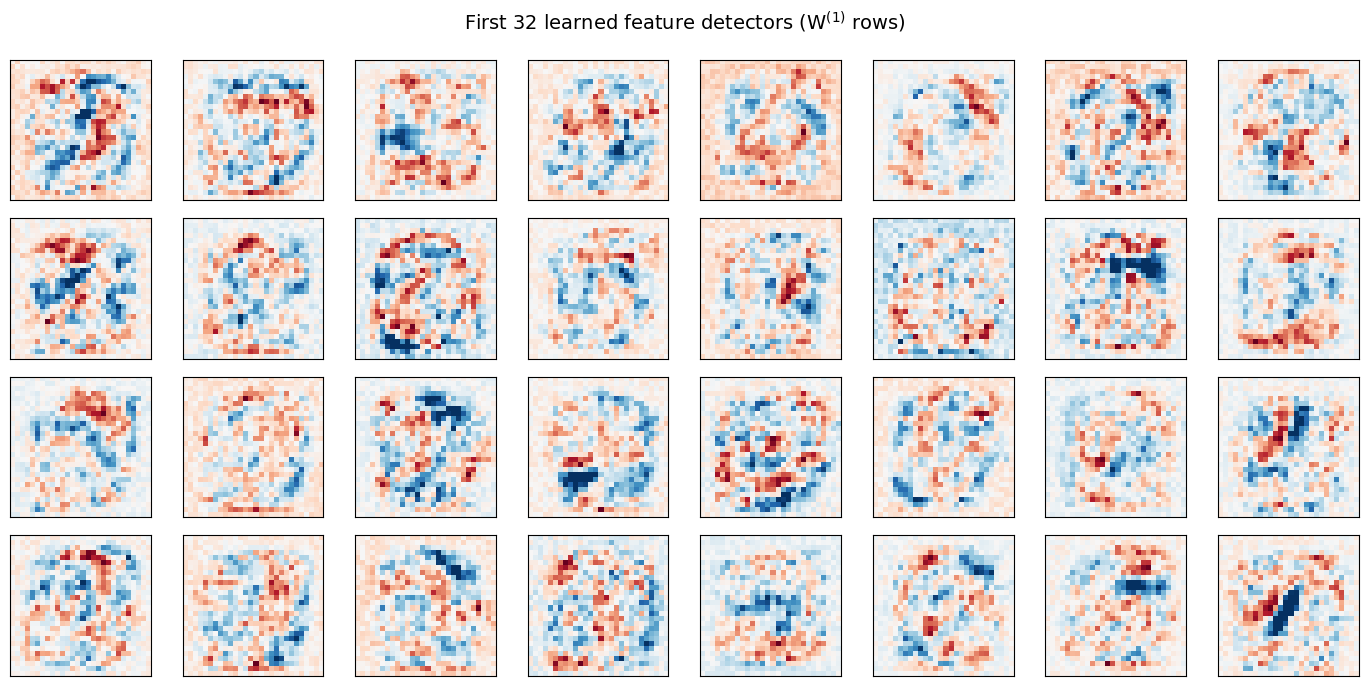

In [25]:
# Use the [128] network trained on full data
W_first = net_128.network[0].weight.detach().cpu().numpy()  # shape (128, 784)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    w = W_first[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu_r', vmin=-w.max(), vmax=w.max())
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('First 32 learned feature detectors (W$^{(1)}$ rows)', fontsize=14)
plt.tight_layout(); plt.show()

Many of these feature detectors pick up edges, strokes, and curves at specific locations in the image — they are looking for local structure that helps distinguish digits.

### (h) Error analysis

219 misclassified out of 10000


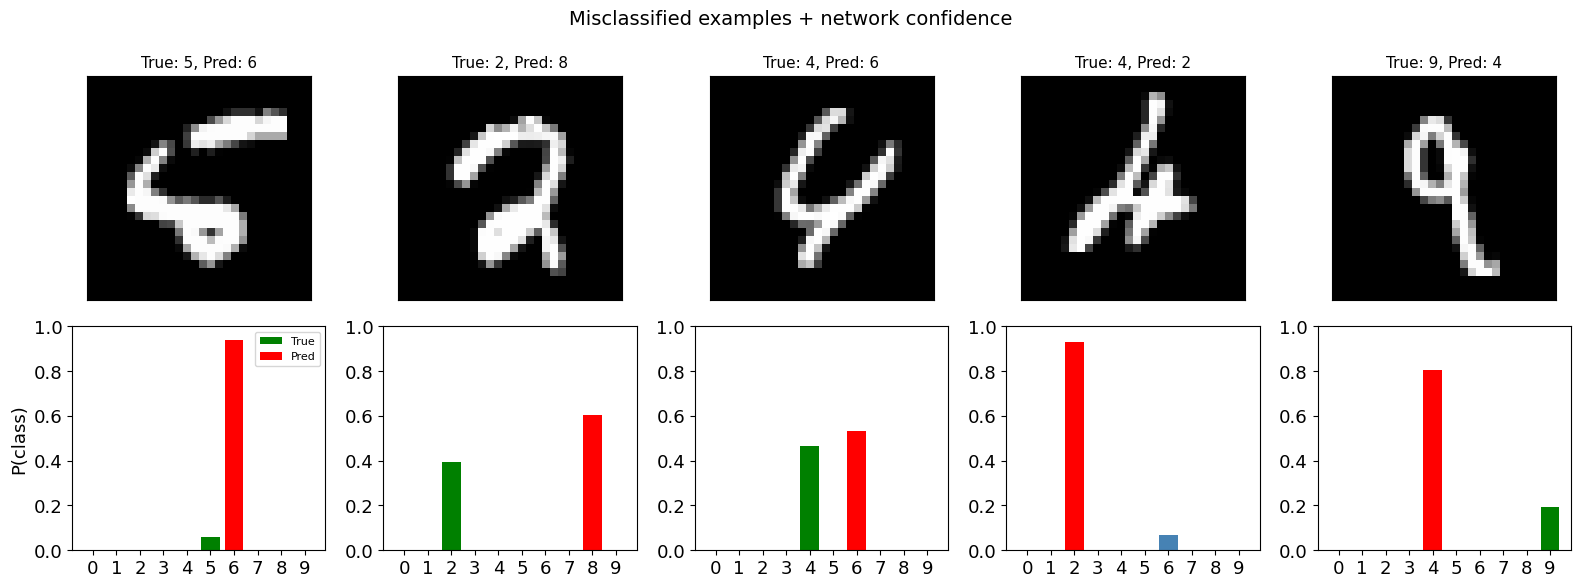

In [26]:
acc_best, preds_best, labels_best = evaluate(net_128, test_loader)

# Get misclassified indices
wrong_idx = np.where(preds_best != labels_best)[0]
print(f'{len(wrong_idx)} misclassified out of {len(labels_best)}')

# Get full probability distributions
net_128.eval()
all_probs = []
with torch.no_grad():
    for X_b, _ in test_loader:
        X_b = X_b.to(device)
        logits = net_128(X_b)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
all_probs = np.concatenate(all_probs)

# Plot 5 misclassified examples
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i in range(5):
    idx = wrong_idx[i]
    # Image
    axes[0, i].imshow(X_test_np[idx].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'True: {labels_best[idx]}, Pred: {preds_best[idx]}', fontsize=11)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    # Probability bar chart
    axes[1, i].bar(range(10), all_probs[idx], color='steelblue')
    axes[1, i].bar(labels_best[idx], all_probs[idx, labels_best[idx]], color='green', label='True')
    axes[1, i].bar(preds_best[idx], all_probs[idx, preds_best[idx]], color='red', label='Pred')
    axes[1, i].set_xticks(range(10))
    axes[1, i].set_ylim(0, 1)
    if i == 0:
        axes[1, i].set_ylabel('P(class)')
        axes[1, i].legend(fontsize=8)

fig.suptitle('Misclassified examples + network confidence', fontsize=14)
plt.tight_layout(); plt.show()

---
# Problem 4: 

Fit $y = \sin(2\pi x) + \epsilon$ using a neural network with ReLU hidden layer and MSE loss (linear output, no activation).

---

In [27]:
np.random.seed(42)
X_reg = np.linspace(0, 1, 200).reshape(-1, 1)
y_reg = np.sin(2 * np.pi * X_reg).ravel() + 0.2 * np.random.randn(200)

X_reg_t = torch.tensor(X_reg, dtype=torch.float32).to(device)
y_reg_t = torch.tensor(y_reg, dtype=torch.float32).to(device)


class RegNet(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, H), nn.ReLU(), nn.Linear(H, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

### (a) Train with H = 1, 5, 20, 100

H=  1 | Final MSE = 0.22432
H=  5 | Final MSE = 0.16935
H= 20 | Final MSE = 0.03433
H=100 | Final MSE = 0.03222


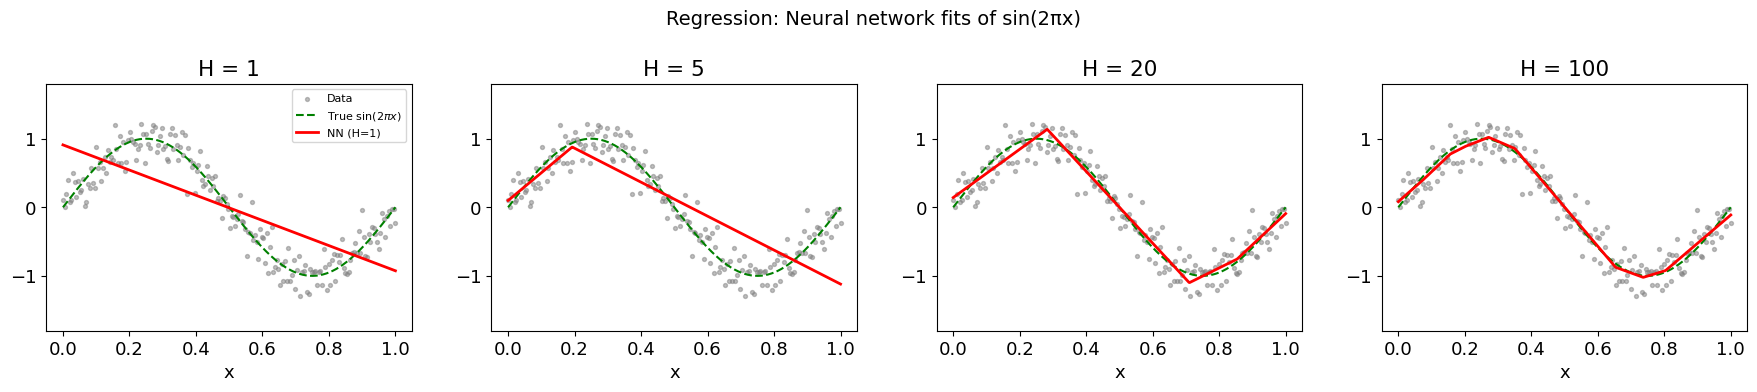

In [28]:
H_values = [1, 5, 20, 100]
reg_models = {}

for H in H_values:
    torch.manual_seed(42)
    model = RegNet(H).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    for epoch in range(8000):
        optimizer.zero_grad()
        loss = criterion(model(X_reg_t), y_reg_t)
        loss.backward()
        optimizer.step()

    reg_models[H] = model
    print(f'H={H:3d} | Final MSE = {loss.item():.5f}')

# Plot
x_dense = np.linspace(0, 1, 500).reshape(-1, 1)
x_dense_t = torch.tensor(x_dense, dtype=torch.float32).to(device)
y_true_curve = np.sin(2 * np.pi * x_dense).ravel()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, H in enumerate(H_values):
    ax = axes[i]
    reg_models[H].eval()
    with torch.no_grad():
        y_fit = reg_models[H](x_dense_t).cpu().numpy()
    ax.scatter(X_reg, y_reg, s=8, alpha=0.5, color='gray', label='Data')
    ax.plot(x_dense, y_true_curve, 'g--', lw=1.5, label='True $\\sin(2\\pi x)$')
    ax.plot(x_dense, y_fit, 'r-', lw=2, label=f'NN (H={H})')
    ax.set_title(f'H = {H}')
    ax.set_xlabel('x'); ax.set_ylim(-1.8, 1.8)
    if i == 0: ax.legend(fontsize=8)

fig.suptitle('Regression: Neural network fits of sin(2πx)', fontsize=14)
plt.tight_layout(); plt.show()

### (b) Discussion

In Module 1, high-order polynomials overfit badly — the fit oscillates wildly between data points because each polynomial basis function is global (high powers of $x$ blow up).

The neural network with $H=100$ does not overfit nearly as much, for two reasons:

1. **ReLU produces local, bounded features.** Each hidden neuron computes $\max(0, w x + b)$, which is a piecewise-linear function that only activates in part of the input space. This is much gentler than $x^{20}$.

2. **Gradient descent is an implicit regularizer.** The optimizer starts from small random weights and takes small steps. It converges to a smooth solution before it has a chance to find the jagged, overfitting minimum that a high-order polynomial fit finds analytically. This is sometimes called the "implicit bias" of gradient descent toward low-complexity solutions.